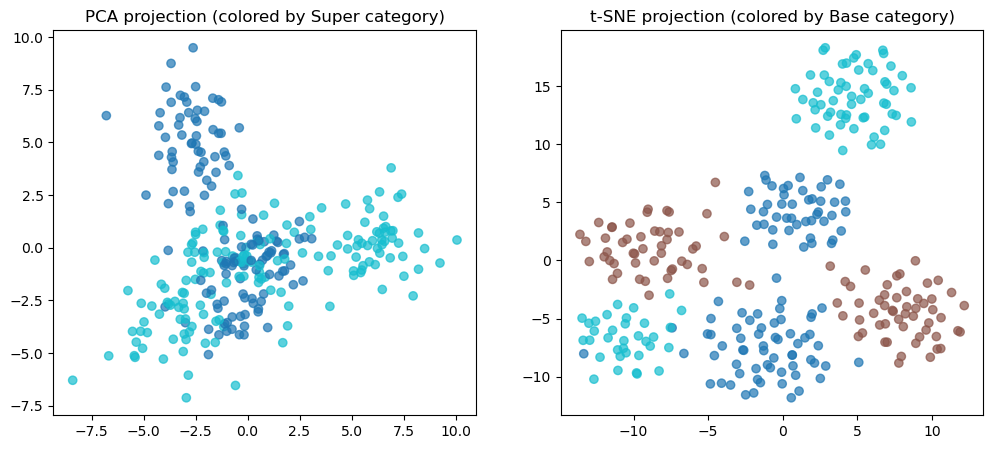

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def generate_hierarchical_dataset(
    n_docs=300,
    vocab_size=50,
    doc_length=100,
    n_super=2,
    n_base=3,
    n_components=10,
    alpha_comp=0.5,  # Dirichlet prior for multinomial components
    seed=0
):
    rng = np.random.default_rng(seed)

    # Step 1: Define multinomial components with Dirichlet prior
    # Shape: (n_super, n_base, n_components, vocab_size)
    components = rng.dirichlet([alpha_comp] * vocab_size,
                               size=(n_super, n_base, n_components))

    docs = []
    labels_super = []
    labels_base = []
    labels_comp = []

    for _ in range(n_docs):
        super_idx = rng.integers(0, n_super)
        base_idx = rng.integers(0, n_base)

        # Uniform weights across components
        comp_weights = np.ones(n_components) / n_components
        comp_ids = rng.choice(n_components, size=doc_length, p=comp_weights)

        # Sample words for each token
        words = [rng.choice(vocab_size, p=components[super_idx, base_idx, c])
                 for c in comp_ids]

        docs.append(words)
        labels_super.append(super_idx)
        labels_base.append(base_idx)
        labels_comp.append(comp_ids[0])  # just tag doc with first comp for visualization

    docs = np.array(docs)
    return (
        jnp.array(docs),          # shape (n_docs, doc_length)
        jnp.array(labels_super),  # shape (n_docs,)
        jnp.array(labels_base),   # shape (n_docs,)
        jnp.array(labels_comp),   # shape (n_docs,)
        jnp.array(components)     # shape (n_super, n_base, n_components, vocab_size)
    )


def docs_to_bow(docs, vocab_size):
    """Convert docs (n_docs, doc_length) into bag-of-words counts."""
    n_docs, doc_length = docs.shape
    bow = np.zeros((n_docs, vocab_size))
    for i in range(n_docs):
        counts = np.bincount(np.array(docs[i]), minlength=vocab_size)
        bow[i] = counts
    return bow


# ==== Generate & visualize ====
docs, labels_super, labels_base, labels_comp, components = generate_hierarchical_dataset(
    n_docs=300, vocab_size=50, doc_length=100, seed=42
)

# Convert to bag-of-words
bow = docs_to_bow(np.array(docs), vocab_size=50)

# Reduce dimension (try PCA first, then t-SNE for more separation)
emb_pca = PCA(n_components=2).fit_transform(bow)
emb_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(bow)

# --- Visualization ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Super-category color
axs[0].scatter(emb_pca[:, 0], emb_pca[:, 1], c=np.array(labels_super), cmap="tab10", alpha=0.7)
axs[0].set_title("PCA projection (colored by Super category)")

# Base-category color
axs[1].scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=np.array(labels_base), cmap="tab10", alpha=0.7)
axs[1].set_title("t-SNE projection (colored by Base category)")

plt.show()


In [5]:
import jax
import jax.numpy as jnp
import numpy as np

def generate_hierarchical_dataset(
    key,
    n_docs=300,
    vocab_size=50,
    n_components=10,
    n_super=2,
    n_base_per_super=3,
    doc_length=100,
    alpha_super=1.0,
    alpha_base=1.0,
    alpha_mix=1.0,
):
    """
    Generate synthetic documents from a hierarchical structure:
    - 2 super categories
    - each with 3 base categories
    - each base category is a mixture of 10 shared components
    - components are Multinomial distributions over vocabulary
    """

    # 1. Shared component distributions
    key, subk = jax.random.split(key)
    component_word_dists = jax.random.dirichlet(
        subk, jnp.ones(vocab_size), shape=(n_components,)
    )  # (n_components, vocab_size)

    # 2. Super-category → base-category mixture
    # Each super has a distribution over its 3 bases
    key, subk = jax.random.split(key)
    super_to_base = jax.random.dirichlet(
        subk, alpha_base * jnp.ones(n_base_per_super), shape=(n_super,)
    )  # (n_super, n_base_per_super)

    # 3. Base-category → component mixture
    key, subk = jax.random.split(key)
    base_to_comp = jax.random.dirichlet(
        subk, alpha_mix * jnp.ones(n_components),
        shape=(n_super * n_base_per_super,)
    )  # (n_super*n_base_per_super, n_components)

    # Generate documents
    docs = []
    super_labels = []
    base_labels = []

    for d in range(n_docs):
        key, subk1, subk2, subk3 = jax.random.split(key, 4)

        # sample super category
        super_id = int(jax.random.randint(subk1, (), 0, n_super))
        # sample base category
        base_id_local = int(jax.random.choice(subk2, n_base_per_super, p=super_to_base[super_id]))
        base_id = super_id * n_base_per_super + base_id_local

        # sample component mixture for this base
        comp_mix = base_to_comp[base_id]

        # sample components for each word in document
        comp_ids = jax.random.choice(subk3, n_components, (doc_length,), p=comp_mix)

        # sample words from chosen components
        key, *subks = jax.random.split(key, doc_length+1)
        subks = jnp.array(subks)
        words = jnp.array([
            jax.random.choice(subks[i], vocab_size, p=component_word_dists[comp_ids[i]])
            for i in range(doc_length)
        ])

        docs.append(words)
        super_labels.append(super_id)
        base_labels.append(base_id)

    docs = jnp.stack(docs)                # (n_docs, doc_length)
    super_labels = jnp.array(super_labels)
    base_labels = jnp.array(base_labels)

    return {
        "docs": docs,
        "super_labels": super_labels,
        "base_labels": base_labels,
        "component_word_dists": component_word_dists,
        "super_to_base": super_to_base,
        "base_to_comp": base_to_comp,
    }


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_dataset_full(data, method="pca", label_level="base"):
    """
    Visualize documents and hierarchical distributions, including Super→Component.
    """

    docs = np.array(data["docs"])
    n_docs, doc_length = docs.shape
    vocab_size = int(docs.max()) + 1

    # ---- Bag-of-words representation ----
    bow = np.zeros((n_docs, vocab_size))
    for i in range(n_docs):
        for w in docs[i]:
            bow[i, int(w)] += 1
    bow /= bow.sum(axis=1, keepdims=True)

    if method == "pca":
        coords = PCA(n_components=2).fit_transform(bow)
    else:
        coords = TSNE(n_components=2, init="random", learning_rate="auto").fit_transform(bow)

    labels = np.array(data["super_labels"] if label_level=="super" else data["base_labels"])

    # ---- Plot docs in 2D ----
    plt.figure(figsize=(6, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", alpha=0.7)
    plt.title(f"Documents colored by {label_level} category")
    plt.colorbar(scatter, ticks=range(len(np.unique(labels))))
    plt.show()

    # ---- Super→Base distributions ----
    super_to_base = np.array(data["super_to_base"])
    n_super, n_base_per_super = super_to_base.shape
    fig, axes = plt.subplots(1, n_super, figsize=(4 * n_super, 3), sharey=True)
    if n_super == 1:
        axes = [axes]
    for i in range(n_super):
        axes[i].bar(range(n_base_per_super), super_to_base[i])
        axes[i].set_title(f"Super {i} → Base")
        axes[i].set_xlabel("Base category")
    plt.suptitle("Super→Base distributions")
    plt.show()

    # ---- Base→Component distributions ----
    base_to_comp = np.array(data["base_to_comp"])
    n_base_total, n_components = base_to_comp.shape
    fig, axes = plt.subplots(n_super, n_base_per_super, figsize=(15, 6), sharey=True)
    for i in range(n_super):
        for j in range(n_base_per_super):
            b = i * n_base_per_super + j
            axes[i, j].bar(range(n_components), base_to_comp[b])
            axes[i, j].set_title(f"Super {i}, Base {j}")
    plt.suptitle("Base→Component distributions")
    plt.show()

    # ---- Super→Component distributions ----
    super_to_comp = np.zeros((n_super, n_components))
    for i in range(n_super):
        for j in range(n_base_per_super):
            global_base_idx = i * n_base_per_super + j
            super_to_comp[i] += super_to_base[i, j] * base_to_comp[global_base_idx]

    fig, axes = plt.subplots(1, n_super, figsize=(4 * n_super, 3), sharey=True)
    if n_super == 1:
        axes = [axes]
    for i in range(n_super):
        axes[i].bar(range(n_components), super_to_comp[i])
        axes[i].set_title(f"Super {i} → Component")
        axes[i].set_xlabel("Component")
    plt.suptitle("Super→Component distributions")
    plt.show()

    # ---- Component→Word distributions ----
    comp_word = np.array(data["component_word_dists"])
    fig, axes = plt.subplots(n_components, 1, figsize=(8, 2 * n_components), sharex=True)
    for k in range(n_components):
        axes[k].bar(range(vocab_size), comp_word[k])
        axes[k].set_ylabel(f"C{k}")
    axes[-1].set_xlabel("Vocabulary index")
    plt.suptitle("Component→Word distributions")
    plt.tight_layout()
    plt.show()


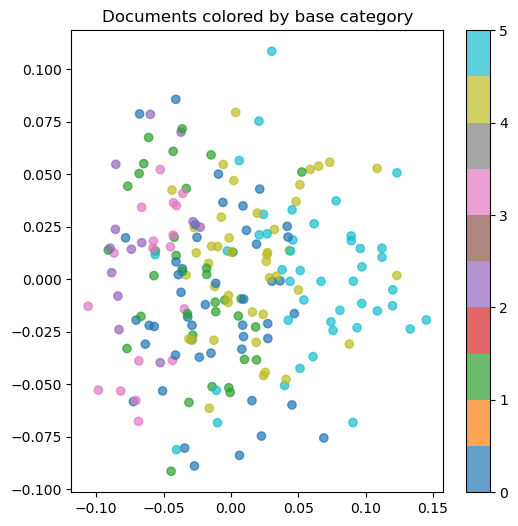

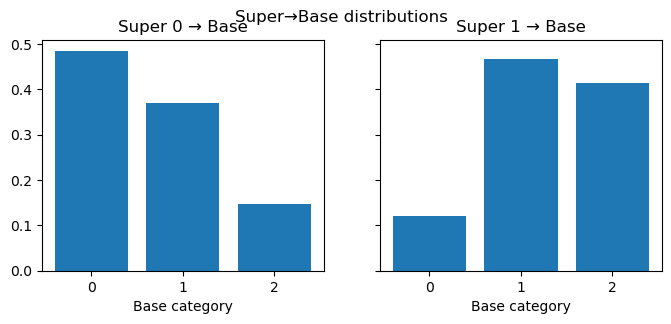

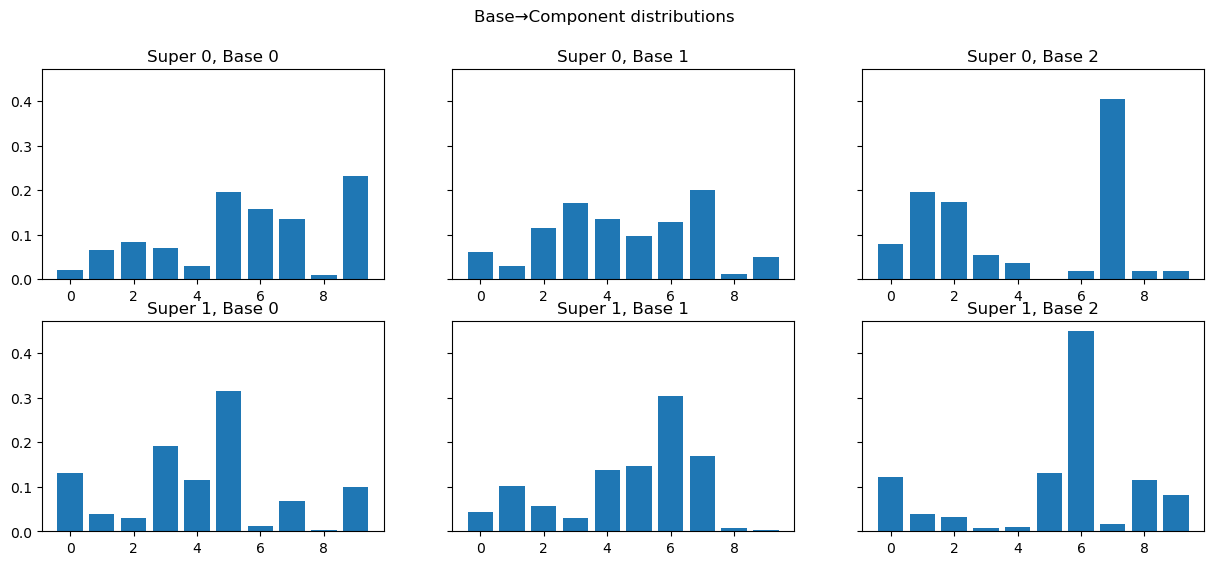

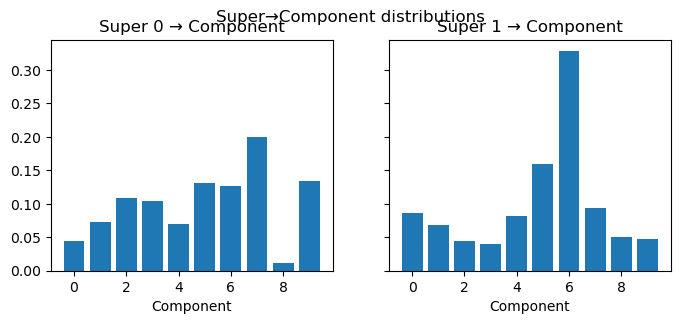

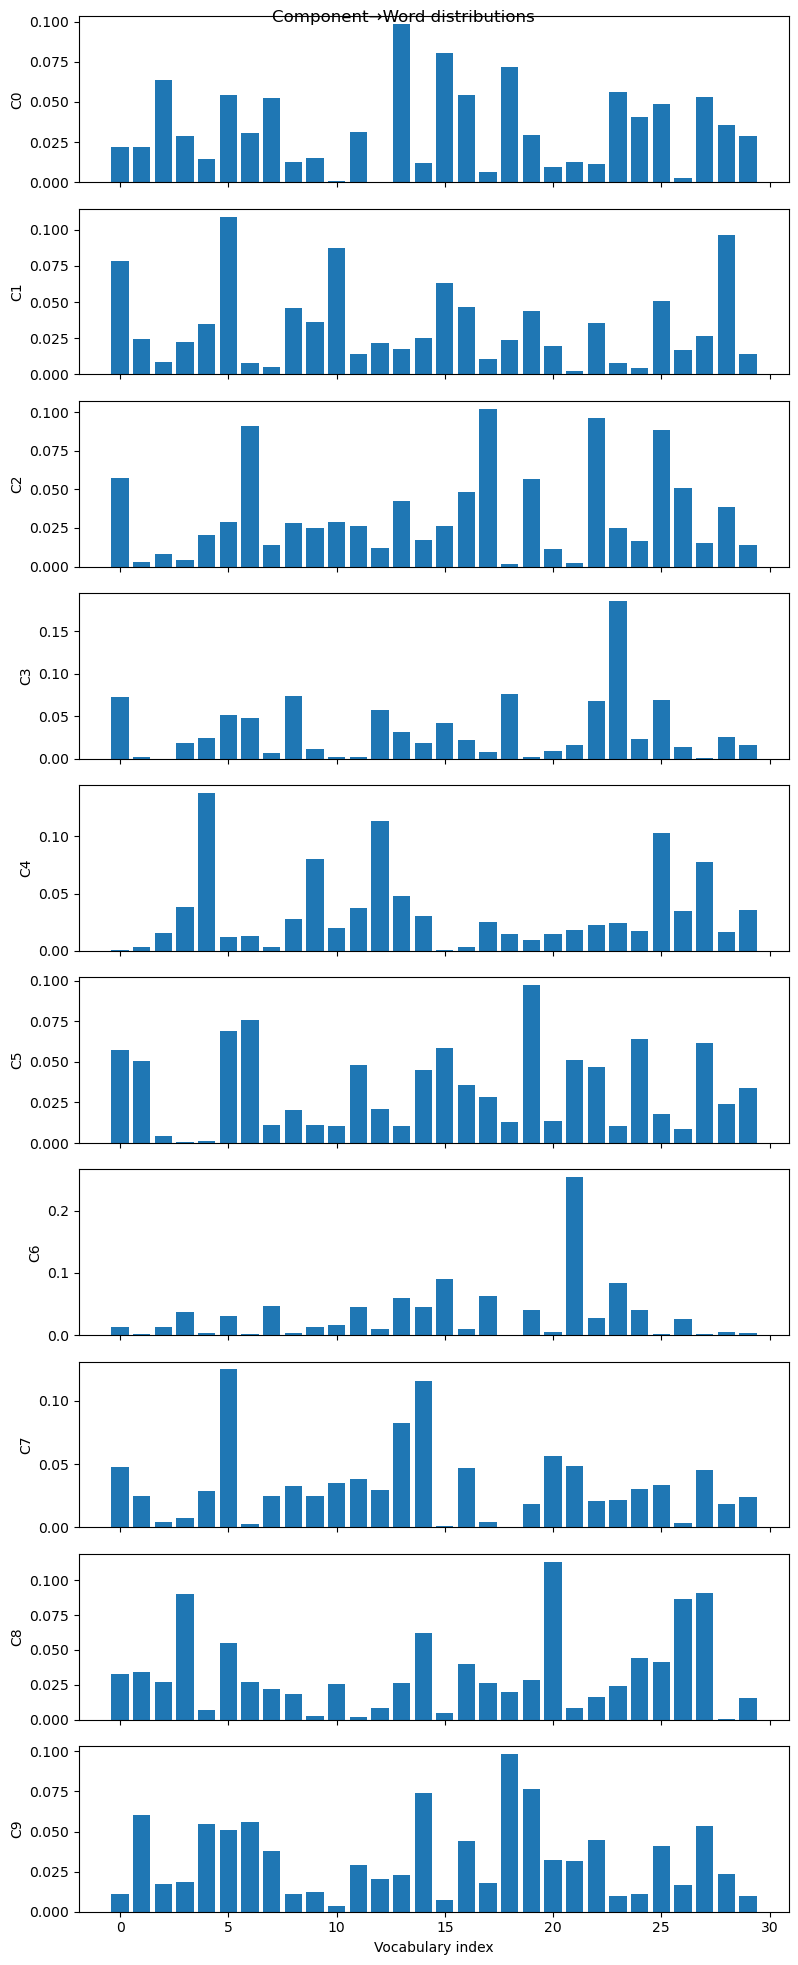

In [13]:
import jax

key = jax.random.PRNGKey(0)
data = generate_hierarchical_dataset(key, n_docs=200, vocab_size=30, doc_length=50)

visualize_dataset_full(data, method="pca", label_level="base")
